<a href="https://colab.research.google.com/github/tonmoy0018/house-Price-Prediction-sample-code-without-built-in-/blob/main/error_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

enter weight:10
enter bias:15
[25. 35. 45. 55. 65.]


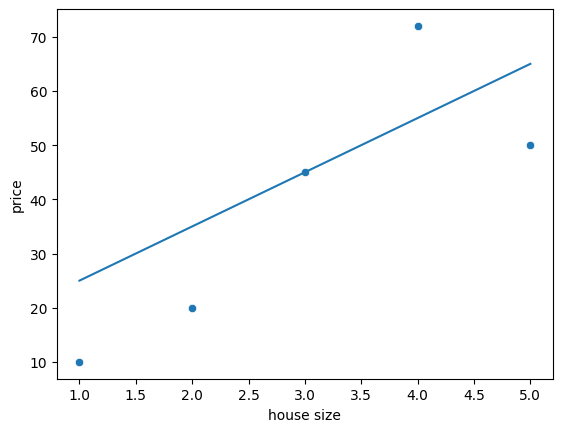

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
x = np.array([1,2,3,4,5])
y = np.array([10,20,45,72,50])
def prediction(x,y,w,b):
  len = x.shape[0]
  predict = np.zeros((len, ))

  for i in range(len):
    predict[i]= w*x[i]+b
  return predict
w = input('enter weight:')
w = int(w)
b = input('enter bias:')
b = int(b)
predicted_value = prediction(x,y,w,b)
print(predicted_value)
plt.xlabel('house size')
plt.ylabel('price')
sns.scatterplot(x = x , y = y)
plt.plot(x , predicted_value)

[25. 35. 45. 55. 65.]


Text(0.5, 1.0, 'Cost: 96.4, for w = 10, b = 15')

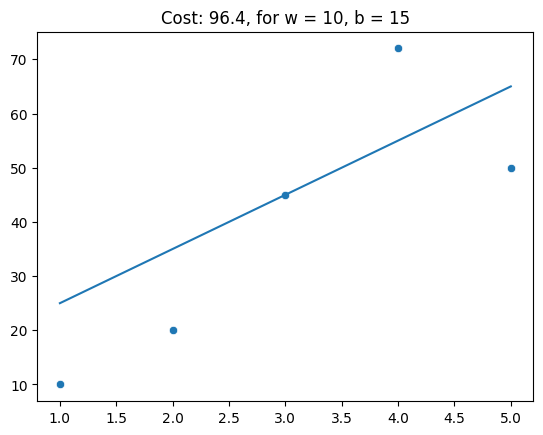

In [2]:
def compute_cost(x,y,w,b):
  cost = 0.0
  m = x.shape[0]

  for i in range(m):
    prediction = w * x[i] + b
    error = prediction - y[i]

    error_squared = error ** 2
    cost = cost + error_squared

  cost = cost/(2 * m)
  return cost

predictions = prediction(x,y, w = w, b = b)

print(predictions)
sns.scatterplot(x = x, y = y)
plt.plot(x,predictions)

plt.title(f"Cost: {compute_cost(x,y,w=w,b=b)}, for w = {w}, b = {b}")

Text(0, 0.5, 'cost')

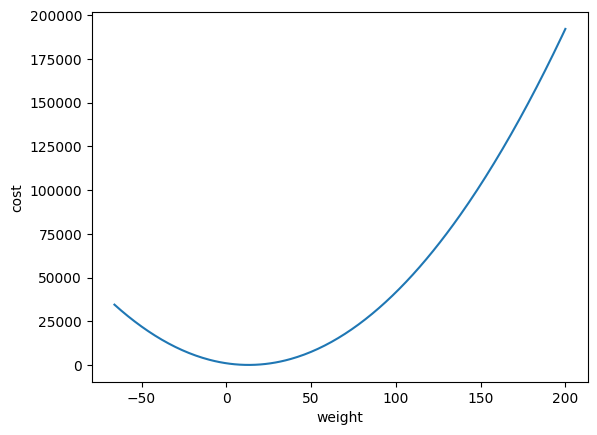

In [3]:
w = []

cost = []

for i in range(-66, 201):
  cost_i = compute_cost(x,y,w=i,b=0)
  w.append(i)
  cost.append(cost_i)


plt.plot(w,cost)
plt.xlabel('weight')
plt.ylabel('cost')



In [15]:
def calculate_gradient(x,y,w,b):

  m = x.shape[0] #number of data points

  dj_dw = 0.0
  dj_db = 0.0

  for i in range(m):
    prediction = w * x[i] + b
    error = prediction - y[i]

    dj_dw = dj_dw + error * x[i]
    dj_db = dj_db + error

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db


In [16]:
calculate_gradient(x,y,w=10, b = 15)

(np.float64(10.4), np.float64(5.6))

In [17]:
def gradient_descent(x, y, w_input, b_input,max_iter, alpha):
  w = w_input
  b = b_input

  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = calculate_gradient(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost_memo.append(compute_cost(x,y,w,b))
    iteration.append(i)

    if i%100 == 0:
      print(f"iteration:{i}, w:{w:.4f}, b:{b:.4f}, dj_dw:{dj_dw:.4f}, dj_db:{dj_db:.4f}, cost:{compute_cost(x,y,w,b)}")

  return w,b, cost_memo, iteration

In [7]:
w,b, cost, iter = gradient_descent(x, y, w_input=0, b_input=0, max_iter=10000, alpha = 0.01)

iteration:0, w:1.4460, b:0.3940, dj_dw:-144.6000, dj_db:-39.4000, cost:809.571628
iteration:100, w:12.3638, b:2.8188, dj_dw:-0.1421, dj_db:0.5111, cost:71.30940532373427
iteration:200, w:12.4940, b:2.3490, dj_dw:-0.1196, dj_db:0.4316, cost:71.0713018614462
iteration:300, w:12.6039, b:1.9522, dj_dw:-0.1009, dj_db:0.3644, cost:70.90155250869844
iteration:400, w:12.6967, b:1.6172, dj_dw:-0.0852, dj_db:0.3077, cost:70.78053434493731
iteration:500, w:12.7750, b:1.3344, dj_dw:-0.0720, dj_db:0.2598, cost:70.69425775110618
iteration:600, w:12.8412, b:1.0955, dj_dw:-0.0608, dj_db:0.2194, cost:70.63274921047261
iteration:700, w:12.8970, b:0.8939, dj_dw:-0.0513, dj_db:0.1852, cost:70.58889837674272
iteration:800, w:12.9442, b:0.7236, dj_dw:-0.0433, dj_db:0.1564, cost:70.55763612276952
iteration:900, w:12.9840, b:0.5799, dj_dw:-0.0366, dj_db:0.1321, cost:70.53534855283401
iteration:1000, w:13.0176, b:0.4585, dj_dw:-0.0309, dj_db:0.1115, cost:70.51945923870922
iteration:1100, w:13.0460, b:0.3560, d

13.19999995547216 -0.19999983924036446
[13.00000012 26.20000007 39.40000003 52.59999998 65.79999994]


Text(0.5, 1.0, 'Cost: 70.47999999999999, for w = 13.19999995547216, b = -0.19999983924036446')

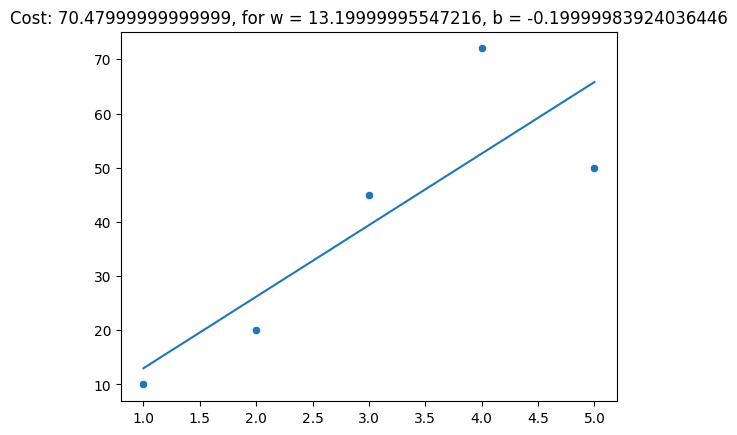

In [8]:
print(w,b)

predictions = prediction(x,y, w = w, b = b)

print(predictions)
sns.scatterplot(x = x, y = y)
plt.plot(x,predictions)
plt.title(f"Cost: {compute_cost(x,y,w=w,b=b)}, for w = {w}, b = {b}")

Text(0, 0.5, 'cost')

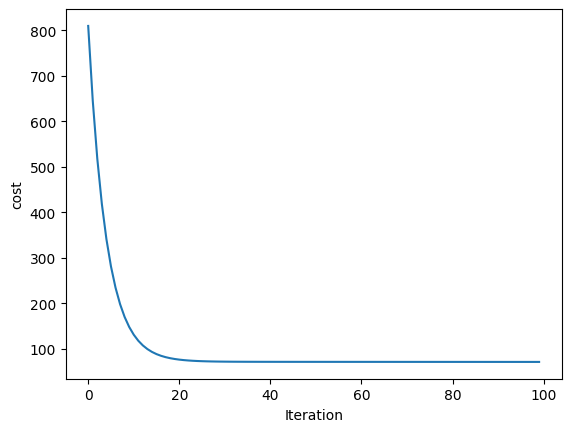

In [11]:
plt.plot(iter[:100], cost[:100])
plt.xlabel('Iteration')
plt.ylabel('cost')


In [14]:
#predicting y with new weight and bias after cost reduction/ error reduction
x1 = 7
y1 = w*x1 + b
y1

np.float64(92.19999984906475)